# Clustering Analysis

**Authors:** Abderrahmane Salmi, Ricardo Talarico, Lorenzo Allegrini

In [133]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
from datetime import datetime

In [134]:
tracks_df = pd.read_csv("../datasets/tracks_prepared.csv")
artists_df = pd.read_csv("../datasets/artists_prepared.csv")

### Select which features will be used

In [135]:
# Print all feature names
tracks_original_features = tracks_df.columns.tolist()
print(tracks_original_features)

# Print total number of features
print(f"\nTotal number of features: {len(tracks_original_features)}")

['id_artist', 'name_artist', 'title', 'featured_artists', 'language', 'stats_pageviews', 'swear_IT', 'swear_EN', 'swear_IT_words', 'swear_EN_words', 'year', 'month', 'day', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'album_name', 'album_release_date', 'album_type', 'track_number', 'duration_ms', 'explicit', 'popularity', 'outlier', 'outlier_score', 'arrapante', 'arrapare', 'arrapato', 'bagascia', 'bastardi', 'bastardo', 'battona', 'bernarda', 'bischero', 'blowjob', 'bocchinaro', 'bocchino', 'bombare', 'cacare', 'cacata', 'cacca', 'cagare', 'cagata', 'cagna', 'cappella', 'cazzata', 'cazzeggiare', 'cazzeggio', 'cazzi', 'cazzo', 'cazzone', 'cazzuto', 'cesso', 'checca', 'chiappa', 'chiavare', 'chiavata', 'cogliona', 'coglionata', 'coglione', 'coglioni', 'controcazzi', 'controcoglioni', 'cornuto', 'cozza', 'cretina', 'cretini', 'cretino', 'culattone', 

In [136]:
# Print all feature names
artists_original_features = artists_df.columns.tolist()
print(artists_original_features)

# Print total number of features
print(f"\nTotal number of features: {len(artists_original_features)}")

['id_author', 'name', 'gender', 'birth_date', 'birth_place', 'nationality', 'description', 'active_start', 'active_end', 'province', 'region', 'country', 'latitude', 'longitude', 'starting_age', 'artist_age', 'birth_year', 'artist_collab_rate']

Total number of features: 18


## Features Selection

In [137]:
selected_features = [
    # linguistic / lyrics
    'n_tokens',
    'tokens_per_sent', 'char_per_tok', 'lexical_density',
    'avg_token_per_clause',

    # audio features
    'bpm', 'centroid', 'rolloff', 'flux',
    'spectral_complexity', 'pitch', 'loudness',

    # popularity
    'popularity', 'relative_popularity',

    # time-related
    # 'season_autumn', 'season_spring', 'season_summer', 'season_winter',

    # engineered features
    'has_collaboration', 'swear_ratio', 'aggressiveness'
]

In [138]:
#Extract feature matrix
X = tracks_df[selected_features].copy()

## Preprocessing (Scaling & Normalization)

In [139]:
# Check for remaining NaNs
print(X.isna().sum())


n_tokens                0
tokens_per_sent         0
char_per_tok            0
lexical_density         0
avg_token_per_clause    0
bpm                     0
centroid                0
rolloff                 0
flux                    0
spectral_complexity     0
pitch                   0
loudness                0
popularity              0
relative_popularity     0
has_collaboration       0
swear_ratio             0
aggressiveness          0
dtype: int64


Skewness of continuous features:


 tokens_per_sent         20.396526
avg_token_per_clause    18.153955
popularity              15.181913
char_per_tok             5.990266
swear_ratio              5.044610
bpm                      1.639578
n_tokens                 1.173797
rolloff                  1.065049
lexical_density          0.599284
relative_popularity      0.265483
pitch                    0.203118
aggressiveness           0.082765
centroid                 0.079253
spectral_complexity     -0.000027
loudness                -0.076856
flux                    -0.182163
dtype: float64


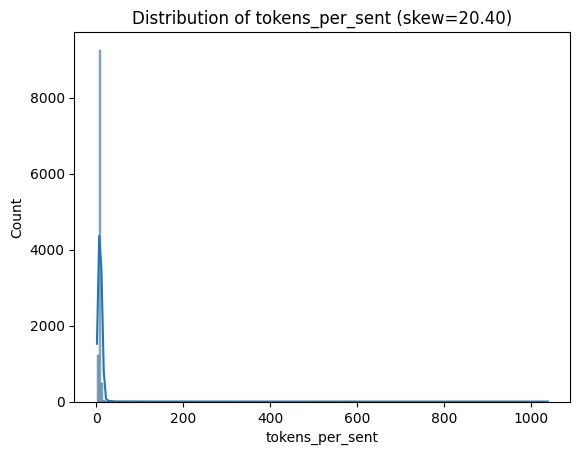

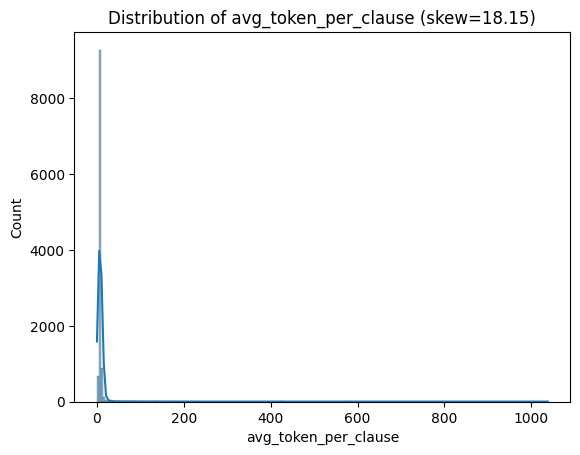

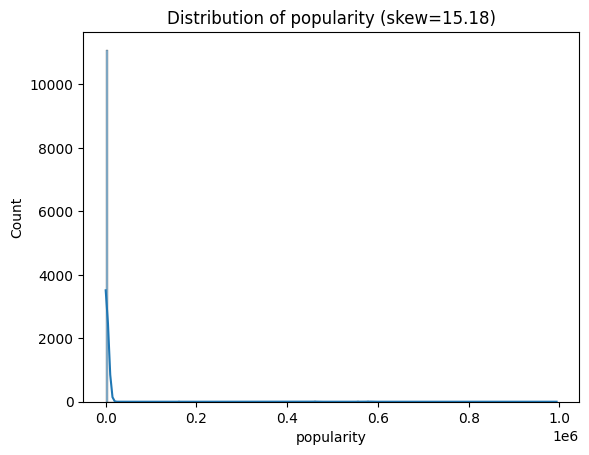

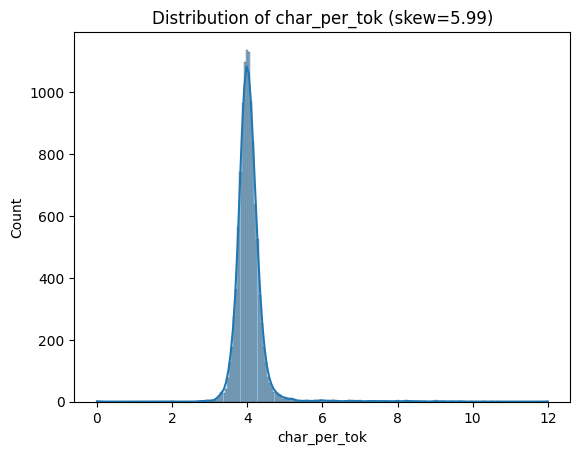

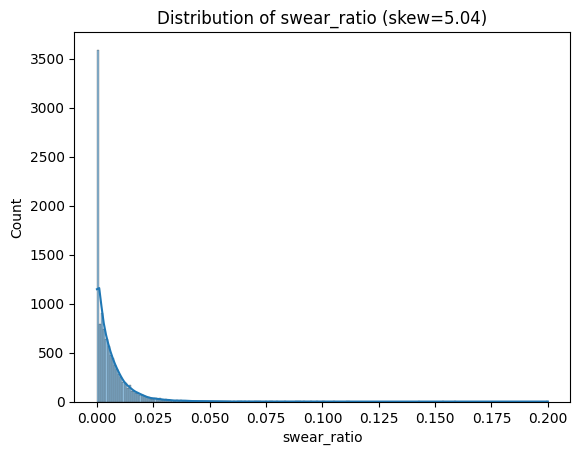

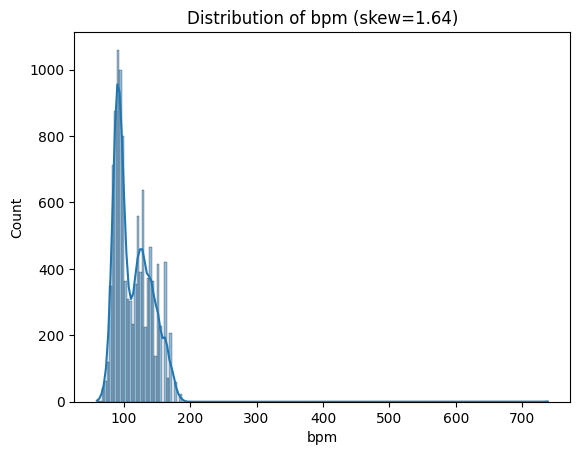

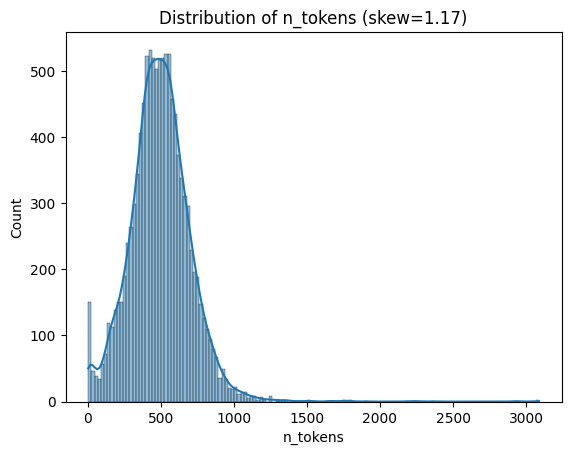

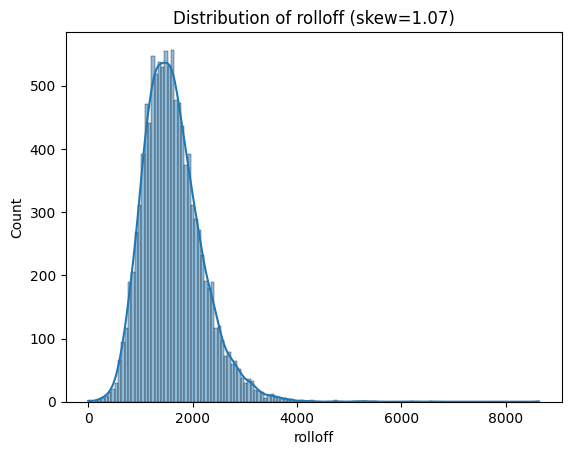

Skewness after log1p transformation:
 tokens_per_sent         6.059600
swear_ratio             4.678938
popularity              2.883568
avg_token_per_clause    2.566924
char_per_tok            0.935688
lexical_density         0.599284
bpm                     0.304275
relative_popularity     0.265483
pitch                   0.203118
aggressiveness          0.082765
centroid                0.079253
spectral_complexity    -0.000027
loudness               -0.076856
flux                   -0.182163
rolloff                -1.305208
n_tokens               -3.454655
dtype: float64


In [140]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features for clustering
numeric_features = X.columns.tolist()  # X is your selected features for clustering

# Step 0: Filter out binary / one-hot encoded features (only keep features with >2 unique values)
continuous_features = [col for col in numeric_features if X[col].nunique() > 2]

# Step 1: Compute skewness
skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness of continuous features:\n", skewness)

# Step 2: Plot distribution of highly skewed features (optional)
high_skew = skewness[skewness > 1].index  # threshold for positive skew
for col in high_skew:
    plt.figure()
    sns.histplot(X[col], kde=True)
    plt.title(f'Distribution of {col} (skew={skewness[col]:.2f})')
    plt.show()

# Step 3: Apply log1p transformation to highly skewed continuous features
for col in high_skew:
    # Only apply if all values are >= 0 (log1p cannot handle negative values)
    if (X[col] >= 0).all():
        X[col] = np.log1p(X[col])
    else:
        print(f"Skipping {col} because it has negative values.")

# Step 4: Verify the new skewness
new_skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness after log1p transformation:\n", new_skewness)

In [141]:
# Scale the features (z-score)
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_zscore = std_scaler.fit_transform(X)

In [142]:
# Scale the features (Min-Max)
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

## K-Means

In [143]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters_zscore = kmeans.fit_predict(X_zscore)

# tracks_df['cluster'] = clusters

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters_minmax = kmeans.fit_predict(X_minmax)

# tracks_df['cluster'] = clusters

### Visualization

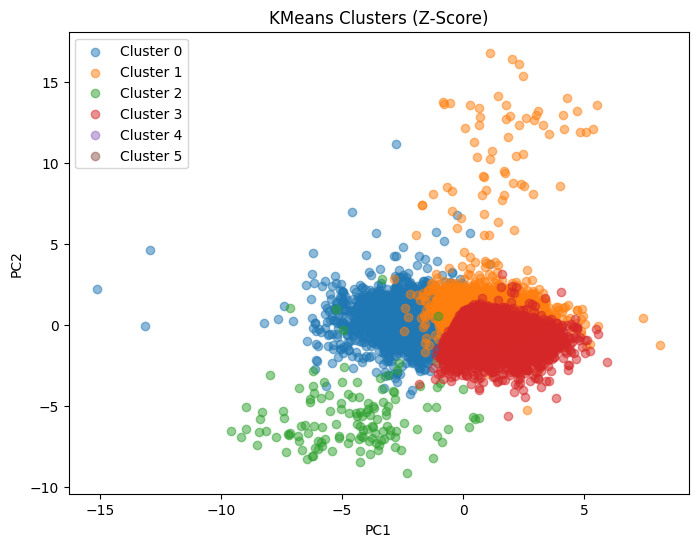

In [145]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_zscore)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in range(kmeans.n_clusters):
    plt.scatter(
        X_pca[clusters_zscore == cluster, 0],
        X_pca[clusters_zscore == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.5
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters (Z-Score)')
plt.legend()
plt.show()


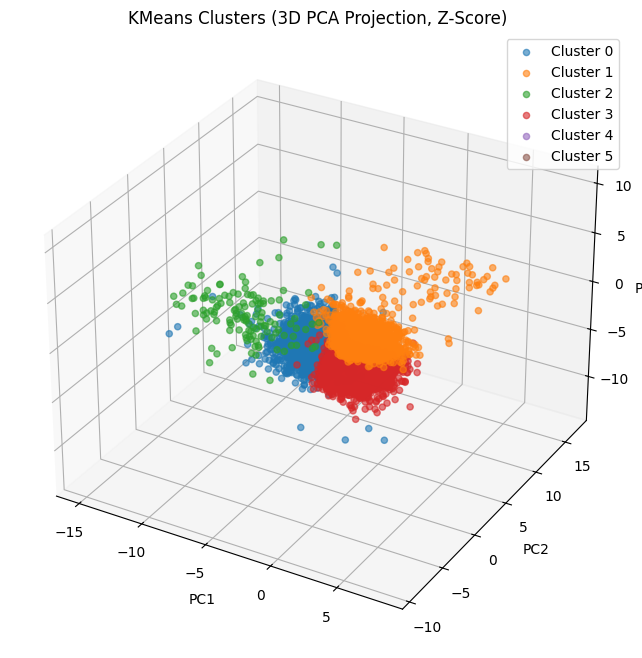

In [146]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required for 3D projection

# PCA to 3 dimensions
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_zscore)

# 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(kmeans.n_clusters):
    ax.scatter(
        X_pca_3d[clusters_zscore == cluster, 0],
        X_pca_3d[clusters_zscore == cluster, 1],
        X_pca_3d[clusters_zscore == cluster, 2],
        label=f'Cluster {cluster}',
        s=20,
        alpha=0.6
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('KMeans Clusters (3D PCA Projection, Z-Score)')
ax.legend()

plt.show()


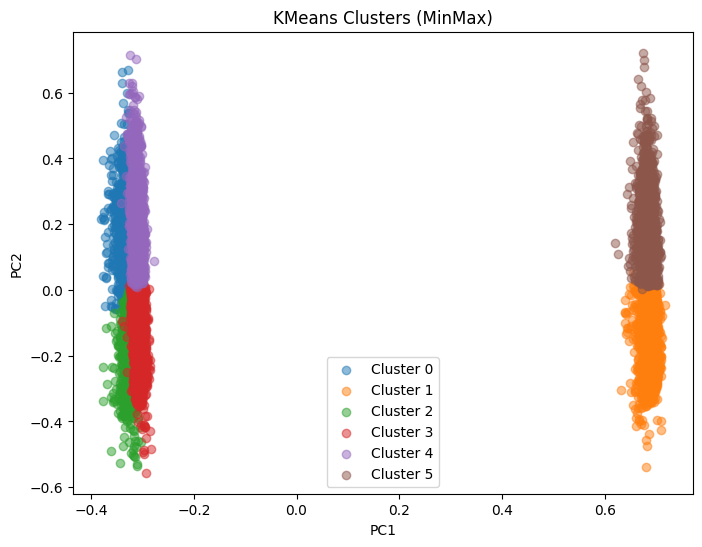

In [147]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_minmax)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in range(kmeans.n_clusters):
    plt.scatter(
        X_pca[clusters_minmax == cluster, 0],
        X_pca[clusters_minmax == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.5
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters (MinMax)')
plt.legend()
plt.show()


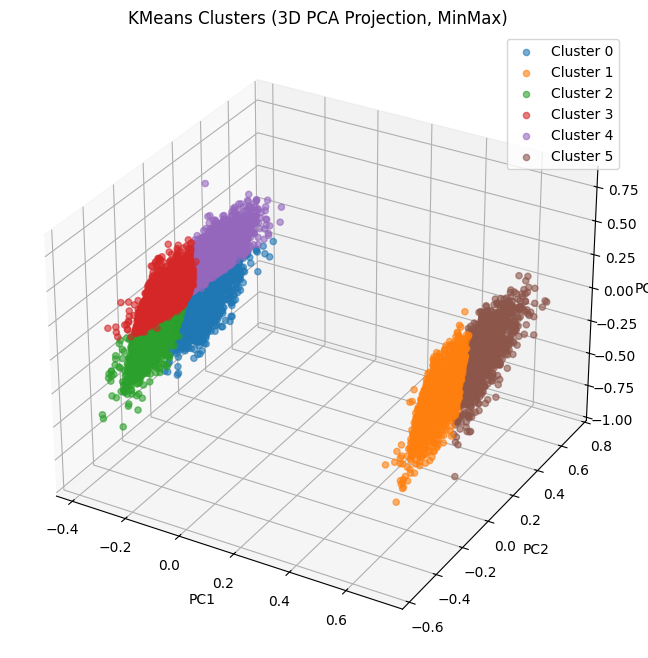

In [148]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots even if unused
import numpy as np

# PCA to 3 dimensions
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_minmax)

# 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(kmeans.n_clusters):
    ax.scatter(
        X_pca_3d[clusters_minmax == cluster, 0],
        X_pca_3d[clusters_minmax == cluster, 1],
        X_pca_3d[clusters_minmax == cluster, 2],
        label=f'Cluster {cluster}',
        s=20,
        alpha=0.6
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('KMeans Clusters (3D PCA Projection, MinMax)')
ax.legend()

plt.show()


### Evaluation

In [149]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_zscore, clusters_zscore)
print(f'Silhouette Score (Zscore): {score:.3f}')


Silhouette Score (Zscore): 0.104


In [150]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_minmax, clusters_minmax)
print(f'Silhouette Score (MinMax): {score:.3f}')


Silhouette Score (MinMax): 0.150


In [151]:
import pandas as pd
import numpy as np

# Get cluster centroids in scaled space
centroids = kmeans.cluster_centers_

# Create a DataFrame for easier reading
centroids_df = pd.DataFrame(centroids, columns=X.columns)

# Compute variance of each column across cluster centers
feature_importance = centroids_df.var(axis=0).sort_values(ascending=False)

print("Feature importance based on centroid variance:")
print(feature_importance)


Feature importance based on centroid variance:
has_collaboration       0.266667
relative_popularity     0.029109
spectral_complexity     0.009972
loudness                0.003670
centroid                0.002381
popularity              0.001959
aggressiveness          0.001530
n_tokens                0.001085
flux                    0.000282
rolloff                 0.000217
pitch                   0.000180
avg_token_per_clause    0.000063
bpm                     0.000042
lexical_density         0.000026
tokens_per_sent         0.000026
swear_ratio             0.000013
char_per_tok            0.000007
dtype: float64


In [152]:
centroids_df


,n_tokens,tokens_per_sent,char_per_tok,lexical_density,avg_token_per_clause,bpm,centroid,rolloff,flux,spectral_complexity,pitch,loudness,popularity,relative_popularity,has_collaboration,swear_ratio,aggressiveness
0,0.647116,0.216371,0.635518,0.511230,0.287039,0.241689,0.401900,0.792283,0.632529,0.325200,0.574551,0.216831,0.190464,0.499536,1.665335e-15,0.028298,0.454943
1,0.726359,0.226417,0.629815,0.521607,0.305898,0.240244,0.462553,0.807152,0.662358,0.445184,0.576453,0.313176,0.272968,0.183671,1.000000e+00,0.034030,0.510168
2,0.681309,0.223902,0.631833,0.512494,0.301429,0.244439,0.391396,0.786775,0.627256,0.310741,0.567165,0.205252,0.285457,0.164403,1.554312e-15,0.027114,0.445571
3,0.714011,0.224923,0.629328,0.518947,0.308198,0.256556,0.481545,0.814107,0.668739,0.491285,0.571794,0.342590,0.273797,0.198877,1.887379e-15,0.035890,0.531996
4,0.714298,0.213554,0.628876,0.508742,0.297810,0.240530,0.510113,0.823910,0.652112,0.560031,0.541730,0.336079,0.197179,0.493999,1.720846e-15,0.032066,0.532383
5,0.735191,0.221369,0.628994,0.510732,0.307063,0.239161,0.490335,0.818030,0.658989,0.494223,0.555709,0.310718,0.204630,0.485671,1.000000e+00,0.034778,0.521962
